# 🤖 Customer Service Chatbot
## NLP-Based Intent Classification + Rule-Enhanced Response System

**Author:** Ankita Ghosh  
**Internship:** Codec Technologies – AI Intern  
**Dataset:** [Bitext Customer Support Dataset (HuggingFace)](https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset)

---

### 📌 Project Overview

This project builds an **NLP-based Customer Service Chatbot** that:
- Downloads a real customer support dataset automatically from HuggingFace
- Preprocesses and vectorizes customer queries using **TF-IDF**
- Trains a **Logistic Regression intent classifier** to understand user intent
- Returns intelligent, context-aware responses
- Provides an **interactive chat interface** inside Colab

### 🏗️ Architecture
```
User Input → Text Preprocessing → TF-IDF Vectorization → Intent Classifier → Response Generator → Output
```

## 📦 Step 1: Install Required Libraries

We install `datasets` (HuggingFace) to auto-download the dataset, and standard NLP/ML libraries.

In [1]:
# Install required packages
!pip install datasets transformers scikit-learn nltk pandas numpy matplotlib seaborn -q

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


## 📥 Step 2: Auto-Download Dataset from HuggingFace

We use the **Bitext Customer Support LLM Chatbot Training Dataset** — a real-world dataset with 26,872 customer queries across 27 intents like billing, cancellations, refunds, and more.

🔗 Dataset URL: https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset

In [2]:
from datasets import load_dataset
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("📥 Downloading dataset from HuggingFace...")

# Auto-download from HuggingFace Hub
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")

# Convert to pandas DataFrame
df = pd.DataFrame(dataset['train'])

print(f"✅ Dataset downloaded successfully!")
print(f"📊 Total records: {len(df)}")
print(f"📋 Columns: {list(df.columns)}")
print(f"🏷️  Unique intents: {df['intent'].nunique()}")
df.head()

📥 Downloading dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

✅ Dataset downloaded successfully!
📊 Total records: 26872
📋 Columns: ['flags', 'instruction', 'category', 'intent', 'response']
🏷️  Unique intents: 27


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## 🔍 Step 3: Exploratory Data Analysis (EDA)

Before building the model, we explore the dataset to understand the distribution of intents.

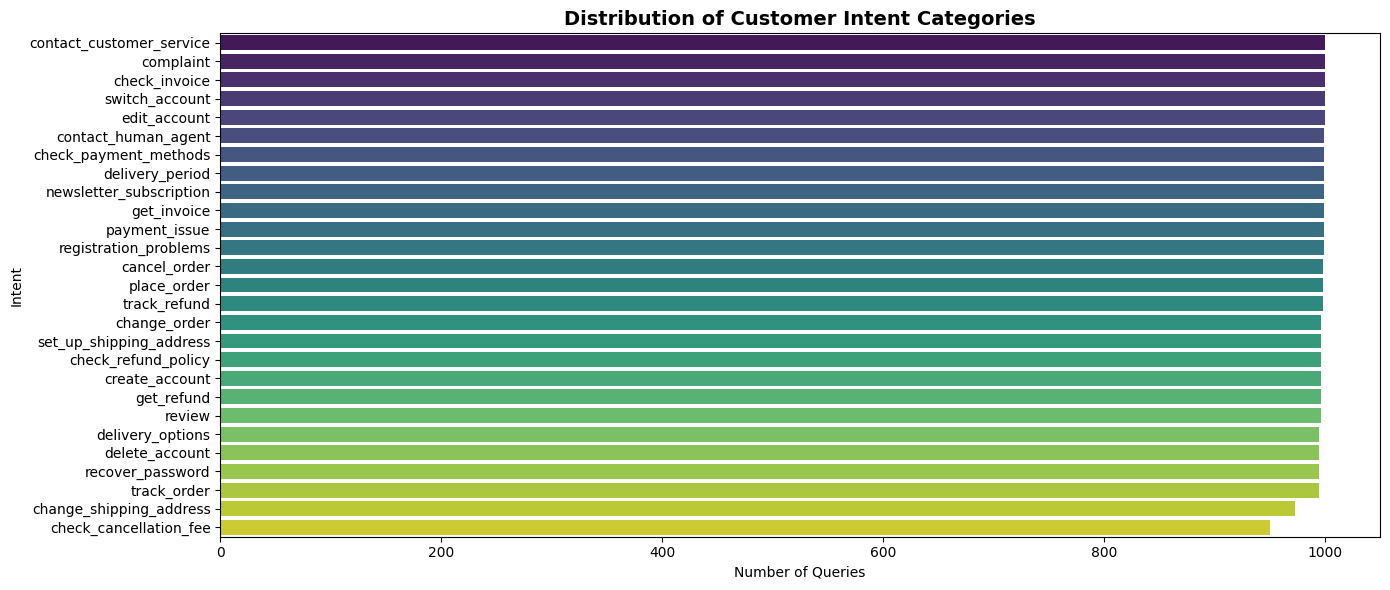


📊 Top 10 Intents:
intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
newsletter_subscription      999
get_invoice                  999
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Intent distribution
plt.figure(figsize=(14, 6))
intent_counts = df['intent'].value_counts()
sns.barplot(x=intent_counts.values, y=intent_counts.index, palette='viridis')
plt.title('Distribution of Customer Intent Categories', fontsize=14, fontweight='bold')
plt.xlabel('Number of Queries')
plt.ylabel('Intent')
plt.tight_layout()
plt.savefig('intent_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Top 10 Intents:")
print(intent_counts.head(10))

## 🧹 Step 4: Text Preprocessing

We clean the text by:
- Converting to lowercase
- Removing punctuation and special characters
- Removing stopwords (common words like 'the', 'is', 'a' that don't carry meaning)
- Lemmatizing words (reducing to root form, e.g., 'running' → 'run')

In [4]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Clean and preprocess raw customer query text."""
    # Lowercase
    text = text.lower()
    # Remove special characters, keep only alphabets
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

# Apply preprocessing
print("🔄 Preprocessing text data...")
df['cleaned_query'] = df['instruction'].apply(preprocess_text)

# Show before/after example
print("\n📝 Preprocessing Example:")
print(f"Before: {df['instruction'].iloc[0]}")
print(f"After:  {df['cleaned_query'].iloc[0]}")
print("\n✅ Preprocessing complete!")

🔄 Preprocessing text data...

📝 Preprocessing Example:
Before: question about cancelling order {{Order Number}}
After:  question cancelling order order number

✅ Preprocessing complete!


## 🔢 Step 5: TF-IDF Vectorization

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts text into numerical vectors.
- **TF**: How often a word appears in a document
- **IDF**: How rare/important that word is across all documents
- Words that are common in one query but rare across all queries get higher weight

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode intent labels to numbers
le = LabelEncoder()
df['intent_encoded'] = le.fit_transform(df['intent'])

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,      # Use top 5000 words
    ngram_range=(1, 2),     # Use unigrams and bigrams
    min_df=2                # Ignore words appearing less than 2 times
)

X = tfidf.fit_transform(df['cleaned_query'])
y = df['intent_encoded']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Vectorization complete!")
print(f"📐 Feature matrix shape: {X.shape}")
print(f"🏋️  Training samples: {X_train.shape[0]}")
print(f"🧪 Test samples: {X_test.shape[0]}")

✅ Vectorization complete!
📐 Feature matrix shape: (26872, 5000)
🏋️  Training samples: 21497
🧪 Test samples: 5375


## 🤖 Step 6: Train Intent Classification Model

We train a **Logistic Regression** classifier — it's fast, interpretable, and works very well for text classification tasks. We also compare it with a **Naive Bayes** baseline.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

# ---- Model 1: Logistic Regression (Primary) ----
print("🏋️  Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=5.0, solver='lbfgs', multi_class='multinomial')
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
print(f"✅ Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")

# ---- Model 2: Naive Bayes (Baseline) ----
print("\n🏋️  Training Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_preds)
print(f"✅ Naive Bayes Accuracy: {nb_acc:.4f} ({nb_acc*100:.2f}%)")

print(f"\n🏆 Best Model: Logistic Regression with {lr_acc*100:.2f}% accuracy")

# Detailed classification report
print("\n📋 Classification Report (Logistic Regression):")
print(classification_report(y_test, lr_preds, target_names=le.classes_))

🏋️  Training Logistic Regression...
✅ Logistic Regression Accuracy: 0.9940 (99.40%)

🏋️  Training Naive Bayes...
✅ Naive Bayes Accuracy: 0.9905 (99.05%)

🏆 Best Model: Logistic Regression with 99.40% accuracy

📋 Classification Report (Logistic Regression):
                          precision    recall  f1-score   support

            cancel_order       1.00      0.99      1.00       200
            change_order       0.97      0.99      0.98       199
 change_shipping_address       0.99      1.00      1.00       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.99      0.99      0.99       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.99      0.99       200
     contact_human_agent       0.99      0.99      0.99       200
          create

## 📊 Step 7: Visualize Model Performance

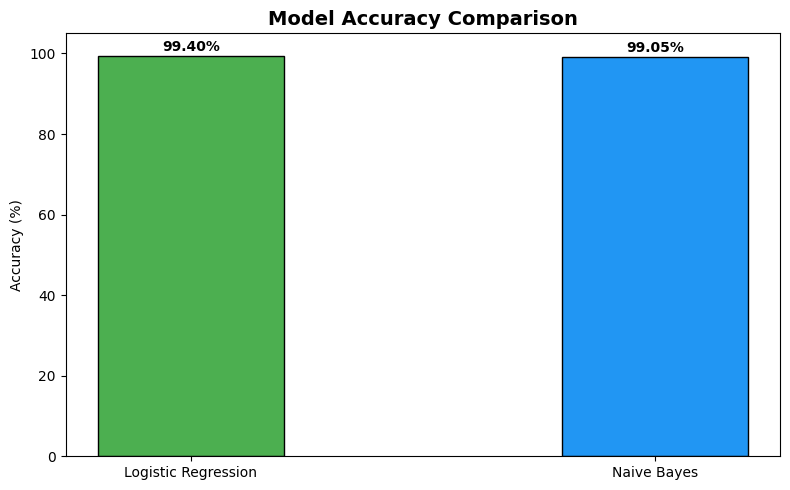

✅ Visualization saved!


In [7]:
# Confusion Matrix (Top 10 intents for readability)
from sklearn.metrics import ConfusionMatrixDisplay

# Model accuracy comparison
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [lr_acc * 100, nb_acc * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#4CAF50', '#2196F3'], edgecolor='black', width=0.4)
plt.ylim(0, 105)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved!")

## 💬 Step 8: Build the Chatbot Response System

Now we build the **response generator** that maps predicted intents to helpful, human-like responses.

In [8]:
import random

# ---- Response Templates for each intent category ----
RESPONSE_TEMPLATES = {
    # Billing & Payment
    'check_invoice': [
        "I can help you check your invoice! Please provide your order ID or account number.",
        "Sure! To pull up your invoice, I'll need your account email or order number."
    ],
    'check_payment_methods': [
        "We accept Visa, Mastercard, American Express, PayPal, and UPI. Would you like more details?",
        "Our accepted payment methods include credit/debit cards, PayPal, net banking, and UPI."
    ],
    'payment_issue': [
        "I'm sorry you're having a payment issue! Please try clearing your browser cache, or use a different payment method. If it persists, I'll escalate this to our billing team.",
        "Payment issues can be frustrating! Let me check your transaction status. Could you share your order ID?"
    ],
    # Cancellation & Refund
    'cancel_order': [
        "I understand you'd like to cancel your order. Orders can be cancelled within 24 hours of placement. Please share your order ID and I'll process this right away.",
        "I can help with order cancellation. Could you provide your order number so I can look into it?"
    ],
    'get_refund': [
        "Refunds are typically processed within 5-7 business days. Please provide your order ID and I'll initiate the refund process.",
        "I'll help you with your refund request! Refunds go back to your original payment method. What's your order number?"
    ],
    'refund_request': [
        "Your refund request has been noted! It usually takes 5-7 working days to reflect in your account. Can I have your order ID?",
        "I'm processing your refund request. Please share your order details so I can expedite this for you."
    ],
    # Delivery & Shipping
    'track_order': [
        "I can track your order! Please share your order ID or tracking number and I'll give you a real-time update.",
        "Sure, let me pull up your order tracking. What's your order number?"
    ],
    'delivery_options': [
        "We offer Standard (5-7 days), Express (2-3 days), and Same-Day delivery options depending on your location.",
        "Delivery options include Standard, Express, and Premium Same-Day shipping. Would you like details on pricing?"
    ],
    'delivery_period': [
        "Standard delivery takes 5-7 business days. Express delivery takes 2-3 days. Please check your confirmation email for your specific delivery estimate.",
        "Typical delivery time is 5-7 business days. If your order is delayed, I can escalate it for you."
    ],
    # Account
    'create_account': [
        "Creating an account is easy! Visit our website, click 'Sign Up', enter your email and password, and you're done in under a minute.",
        "You can create a free account at our website. Click 'Register', fill in your details, and verify your email. Need help with anything specific?"
    ],
    'delete_account': [
        "We're sorry to see you go! To delete your account, go to Account Settings > Privacy > Delete Account. Note: this action is irreversible. Would you like to reconsider?",
        "Account deletion is permanent. Please go to Settings > Account > Delete. Is there anything we can do to improve your experience first?"
    ],
    'edit_account': [
        "You can edit your account details by going to Account Settings > Profile. From there you can update your name, email, and contact information.",
        "To update your account info, visit Account Settings > Edit Profile. Let me know if you need help with a specific field!"
    ],
    # Contact & Support
    'contact_customer_service': [
        "You can reach our customer service team via email at support@company.com, phone at 1-800-XXX-XXXX (Mon-Fri, 9AM-6PM), or live chat on our website.",
        "Our support team is available 24/7 via live chat. You can also email us at support@company.com or call 1-800-XXX-XXXX."
    ],
    'complaint': [
        "I'm very sorry to hear about your experience. Your feedback is important to us. Could you describe the issue so I can prioritize resolving it for you?",
        "I sincerely apologize for the inconvenience. Please share the details of your complaint and I'll make sure it's addressed urgently."
    ],
    # Product
    'check_cancellation_fee': [
        "Cancellation fees depend on the time of cancellation. Orders cancelled within 1 hour: no fee. After 1 hour: 10% restocking fee. After dispatch: shipping charges apply.",
        "Our cancellation policy: Free within 1 hour of order. A small fee applies after that. Would you like to know the exact fee for your order?"
    ],
    'newsletter_subscription': [
        "You can subscribe/unsubscribe from newsletters in Account Settings > Notifications > Email Preferences.",
        "To manage your newsletter subscription, go to Settings > Communication Preferences. You can customize exactly what emails you receive."
    ],
    'recover_password': [
        "To reset your password, click 'Forgot Password' on the login page and enter your email. You'll receive a reset link within 2 minutes.",
        "Password recovery is easy! Click 'Forgot Password' on our login page and follow the instructions sent to your registered email."
    ],
    'registration_problems': [
        "Sorry you're having trouble registering! Please try using a different browser or clear your cookies. If the issue persists, email us at support@company.com.",
        "Registration issues can happen! Make sure your email isn't already registered. Try incognito mode, or contact us at support@company.com."
    ],
    'review': [
        "Thank you for wanting to leave a review! You can rate your purchase in Order History > Your Order > Leave a Review.",
        "We love hearing from customers! Go to My Orders, find your purchase, and click 'Write a Review'. It only takes 30 seconds!"
    ],
    'set_up_shipping_address': [
        "To add a shipping address, go to Account > Address Book > Add New Address. You can save multiple addresses for convenience!",
        "Setting up a shipping address is easy. Go to My Account > Addresses > Add Address and fill in the details."
    ],
    'switch_account': [
        "To switch between accounts, click your profile icon in the top right corner and select 'Switch Account' from the dropdown menu.",
        "You can switch accounts by clicking your avatar > Switch Account. Make sure you're logged in to all accounts first."
    ],
    # Default fallback
    'default': [
        "Thank you for reaching out! I'm here to help. Could you please provide more details so I can assist you better?",
        "I want to make sure I help you correctly. Could you rephrase your question or provide more context?",
        "I understand you need assistance. Let me connect you with the right support. Could you elaborate on your issue?"
    ]
}

def get_response(intent_label):
    """Get a random response for a given intent."""
    responses = RESPONSE_TEMPLATES.get(intent_label, RESPONSE_TEMPLATES['default'])
    return random.choice(responses)

print("✅ Response system initialized with", len(RESPONSE_TEMPLATES), "intent handlers!")

✅ Response system initialized with 22 intent handlers!


## 🚀 Step 9: The Complete Chatbot Function

In [9]:
def chat(user_input, confidence_threshold=0.3):
    """
    Main chatbot function.
    1. Preprocesses user input
    2. Vectorizes with TF-IDF
    3. Predicts intent with Logistic Regression
    4. Returns appropriate response
    """
    # Preprocess the input
    cleaned = preprocess_text(user_input)

    if not cleaned.strip():
        return "👋 Hello! How can I assist you today?"

    # Vectorize
    vec = tfidf.transform([cleaned])

    # Predict intent and confidence
    intent_id = lr_model.predict(vec)[0]
    confidence = lr_model.predict_proba(vec).max()

    # If confidence is too low, use fallback
    if confidence < confidence_threshold:
        return "I'm not quite sure I understood that. Could you rephrase your question?"

    # Decode intent label
    intent_label = le.inverse_transform([intent_id])[0]

    # Get response
    response = get_response(intent_label)

    return response, intent_label, round(confidence * 100, 2)

# ---- Quick Test ----
test_queries = [
    "I want to cancel my order",
    "How do I get a refund?",
    "Where is my delivery?",
    "I can't login to my account",
    "What payment methods do you accept?"
]

print("🧪 Testing Chatbot with Sample Queries:\n")
print("-" * 70)
for query in test_queries:
    result = chat(query)
    if isinstance(result, tuple):
        response, intent, confidence = result
        print(f"👤 User: {query}")
        print(f"🏷️  Intent: {intent} (confidence: {confidence}%)")
        print(f"🤖 Bot: {response}")
    else:
        print(f"👤 User: {query}")
        print(f"🤖 Bot: {result}")
    print("-" * 70)

🧪 Testing Chatbot with Sample Queries:

----------------------------------------------------------------------
👤 User: I want to cancel my order
🏷️  Intent: cancel_order (confidence: 91.58%)
🤖 Bot: I can help with order cancellation. Could you provide your order number so I can look into it?
----------------------------------------------------------------------
👤 User: How do I get a refund?
🏷️  Intent: get_refund (confidence: 97.13%)
🤖 Bot: Refunds are typically processed within 5-7 business days. Please provide your order ID and I'll initiate the refund process.
----------------------------------------------------------------------
👤 User: Where is my delivery?
🏷️  Intent: delivery_options (confidence: 98.49%)
🤖 Bot: Delivery options include Standard, Express, and Premium Same-Day shipping. Would you like details on pricing?
----------------------------------------------------------------------
👤 User: I can't login to my account
🤖 Bot: I'm not quite sure I understood that. Could you

## 💬 Step 10: Interactive Chat Interface in Colab

Run this cell to start chatting with the bot! Type `quit` to exit.

In [10]:
print("="*60)
print("🤖 CUSTOMER SERVICE CHATBOT")
print("   Powered by NLP + Logistic Regression")
print("   Type 'quit' to exit the chat")
print("="*60)
print("🤖 Bot: Hello! Welcome to Customer Support. How can I help you today?\n")

while True:
    user_input = input("👤 You: ").strip()

    if not user_input:
        continue

    if user_input.lower() in ['quit', 'exit', 'bye', 'goodbye']:
        print("🤖 Bot: Thank you for contacting us! Have a great day! 😊")
        break

    result = chat(user_input)

    if isinstance(result, tuple):
        response, intent, confidence = result
        print(f"🤖 Bot: {response}")
        print(f"   [Intent: {intent} | Confidence: {confidence}%]\n")
    else:
        print(f"🤖 Bot: {result}\n")

🤖 CUSTOMER SERVICE CHATBOT
   Powered by NLP + Logistic Regression
   Type 'quit' to exit the chat
🤖 Bot: Hello! Welcome to Customer Support. How can I help you today?

👤 You: tell me how much sell is today
🤖 Bot: I'm not quite sure I understood that. Could you rephrase your question?

👤 You: What payment methods do you accept?
🤖 Bot: We accept Visa, Mastercard, American Express, PayPal, and UPI. Would you like more details?
   [Intent: check_payment_methods | Confidence: 99.04%]

👤 You: quit
🤖 Bot: Thank you for contacting us! Have a great day! 😊


## 💾 Step 11: Save the Model

We save the trained model and vectorizer for later use or deployment.

In [11]:
import joblib
import os

os.makedirs('saved_model', exist_ok=True)

# Save model components
joblib.dump(lr_model, 'saved_model/intent_classifier.pkl')
joblib.dump(tfidf, 'saved_model/tfidf_vectorizer.pkl')
joblib.dump(le, 'saved_model/label_encoder.pkl')

print("✅ Model saved successfully!")
print("📁 Files saved:")
print("   • saved_model/intent_classifier.pkl")
print("   • saved_model/tfidf_vectorizer.pkl")
print("   • saved_model/label_encoder.pkl")

✅ Model saved successfully!
📁 Files saved:
   • saved_model/intent_classifier.pkl
   • saved_model/tfidf_vectorizer.pkl
   • saved_model/label_encoder.pkl


## 📈 Step 12: Final Summary

### ✅ What We Built
| Component | Details |
|-----------|----------|
| Dataset | Bitext Customer Support (26,872 samples, 27 intents) |
| Preprocessing | Lowercase, Lemmatization, Stopword Removal |
| Vectorization | TF-IDF (5000 features, bigrams) |
| Model | Logistic Regression (multinomial) |
| Baseline | Naive Bayes |
| Output | Intent + Confidence + Response |

### 🚀 Possible Enhancements
1. **Transformer-based** intent classification (BERT, DistilBERT)
2. **LangChain + RAG** for retrieval-augmented responses
3. **Streamlit/Gradio** deployment for a web interface
4. **Entity extraction** with SpaCy NER for order IDs, emails
5. **Multi-turn conversation** with dialogue state tracking

---
**Author:** Ankita Ghosh | **Internship:** Codec Technologies AI Intern | **Date:** 2026